In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm

from pathlib import Path

In [62]:
BASE_DIR = Path.cwd()
if (BASE_DIR / "DATA").exists() is False:
    BASE_DIR = BASE_DIR.parent

file_path = BASE_DIR / "OUTPUT" / "movies_10y_metadata_with_counts_both.csv"
df = pd.read_csv(file_path)

print("Initial shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Initial shape: (10000, 8)

Columns:
['image_path', 'title', 'popularity', 'release_date', 'image_height', 'image_width', 'person_count_L', 'person_count_UL']


In [63]:
# Cleaning to ensure consistent data types for modeling
# convert release_date to datetime
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

df = df.dropna(subset=[
    "popularity",
    "release_date",
    "person_count_L",
    "person_count_UL",
    "image_width",
    "image_height"
]).copy()

df = df[(df["image_width"] == 500) & (df["image_height"] == 750)].copy()

df["release_year"] = df["release_date"].dt.year

print("\nShape after cleaning:", df.shape)


Shape after cleaning: (10000, 9)


In [64]:
# Evaluate 
def evaluate_model(df, feature_cols, target_col="popularity", log_target=False, model_name="Model"):
    
    data = df.copy()

    if log_target:
        y = np.log1p(data[target_col])
        target_label = f"log({target_col})"
    else:
        y = data[target_col]
        target_label = target_col

    X = data[feature_cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"\n{'='*60}")
    print(model_name)
    print(f"Target used: {target_label}")
    print(f"{'='*60}")
    print("Coefficients:")
    for col, coef in zip(feature_cols, model.coef_):
        print(f"  {col}: {coef:.6f}")
    print(f"Intercept: {model.intercept_:.6f}")

    print("\nTrain Metrics")
    print(f"  RMSE: {train_rmse:.6f}")
    print(f"  MAE : {train_mae:.6f}")
    print(f"  R^2 : {train_r2:.6f}")

    print("\nTest Metrics")
    print(f"  RMSE: {test_rmse:.6f}")
    print(f"  MAE : {test_mae:.6f}")
    print(f"  R^2 : {test_r2:.6f}")

    print("\nSanity check")
    print("  y_test max:", y_test.max())
    print("  y_test min:", y_test.min())

    return {
        "model": model,
        "feature_cols": feature_cols,
        "target_label": target_label,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_r2": train_r2,
        "test_r2": test_r2
    }


def run_statsmodels_ols(df, feature_cols, target_col="popularity", log_target=False, model_name="OLS Model"):
    data = df.copy()

    if log_target:
        y = np.log1p(data[target_col])
        target_label = f"log({target_col})"
    else:
        y = data[target_col]
        target_label = target_col

    X = data[feature_cols]
    X_sm = sm.add_constant(X)

    ols_model = sm.OLS(y, X_sm).fit(cov_type="HC3")

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"Target used: {target_label}")
    print(f"{'='*60}")
    print(ols_model.summary())

    person_var = feature_cols[0]

    print("\nHypothesis test for", person_var)
    print("Coefficient:", ols_model.params[person_var])
    print("P-value:", ols_model.pvalues[person_var])
    print("95% CI:", ols_model.conf_int().loc[person_var].tolist())

    if ols_model.params[person_var] > 0 and ols_model.pvalues[person_var] < 0.05:
        print("Conclusion: statistically significant positive relationship.")
    elif ols_model.params[person_var] > 0:
        print("Conclusion: positive relationship, but NOT statistically significant.")
    else:
        print("Conclusion: relationship is not positive.")

    return ols_model


def plot_actual_vs_predicted(results, title):
    y_true = results["y_test"]
    y_pred = results["y_test_pred"]

    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.4)
    plt.xlabel(f'Actual {results["target_label"]}')
    plt.ylabel(f'Predicted {results["target_label"]}')
    plt.title(title)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.tight_layout()
    plt.savefig(f"{BASE_DIR}/OUTPUT/linreg_plots/{title}_actual_vs_predicted.png", dpi=300)
    plt.show()


def plot_residuals(results, title):
    y_true = results["y_test"]
    y_pred = results["y_test_pred"]
    residuals = y_true - y_pred

    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, linestyle="--")
    plt.xlabel(f'Predicted {results["target_label"]}')
    plt.ylabel("Residuals")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{BASE_DIR}/OUTPUT/linreg_plots/{title}_residuals.png", dpi=300)
    plt.show()

In [65]:
y = df["popularity"]


Baseline: log(popularity) ~ release_year
Target used: log(popularity)
Coefficients:
  release_year: 0.027211
Intercept: -52.150888

Train Metrics
  RMSE: 0.637011
  MAE : 0.465080
  R^2 : 0.015781

Test Metrics
  RMSE: 0.682316
  MAE : 0.479348
  R^2 : 0.017557

Sanity check
  y_test max: 7.148957977830269
  y_test min: 1.823096624537095

Baseline OLS: log(popularity) ~ release_year
Target used: log(popularity)
                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     119.7
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.04e-27
Time:                        19:28:06   Log-Likelihood:                -9824.5
No. Observations:               10000   AIC:                         1.965e+04
Df Residuals:                  

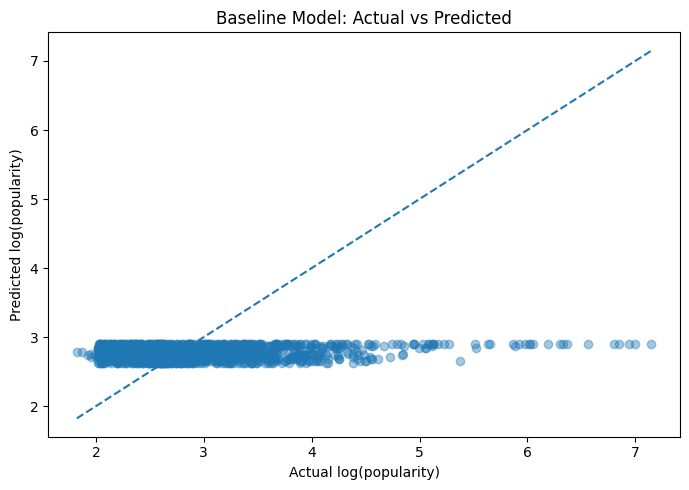

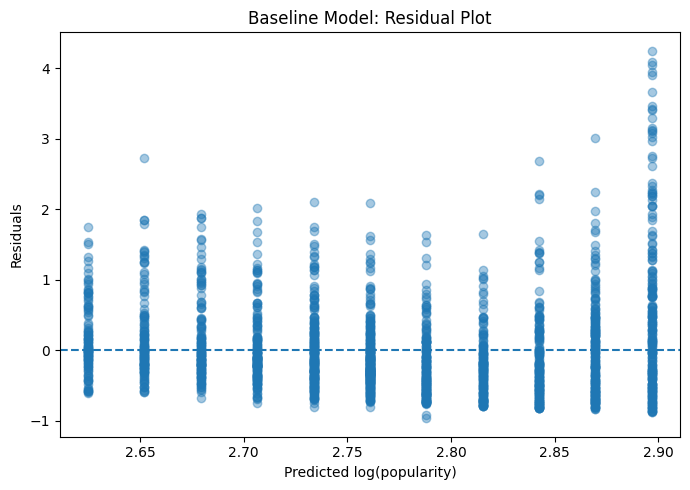

In [66]:
baseline_results = evaluate_model(
    df=df,
    feature_cols=["release_year"],
    target_col="popularity",
    log_target=True,
    model_name="Baseline: log(popularity) ~ release_year"
)

baseline_ols = run_statsmodels_ols(
    df=df,
    feature_cols=["release_year"],
    target_col="popularity",
    log_target=True,
    model_name="Baseline OLS: log(popularity) ~ release_year"
)

plot_actual_vs_predicted(baseline_results, "Baseline Model: Actual vs Predicted")
plot_residuals(baseline_results, "Baseline Model: Residual Plot")


Model L: log(popularity) ~ person_count_L + release_year
Target used: log(popularity)
Coefficients:
  person_count_L: 0.002785
  release_year: 0.027199
Intercept: -52.130886

Train Metrics
  RMSE: 0.636980
  MAE : 0.465150
  R^2 : 0.015877

Test Metrics
  RMSE: 0.682146
  MAE : 0.479295
  R^2 : 0.018047

Sanity check
  y_test max: 7.148957977830269
  y_test min: 1.823096624537095

Model L OLS: log(popularity) ~ person_count_L + release_year
Target used: log(popularity)
                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     60.25
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           9.81e-27
Time:                        19:28:07   Log-Likelihood:                -9823.5
No. Observations:               10000   AIC:       

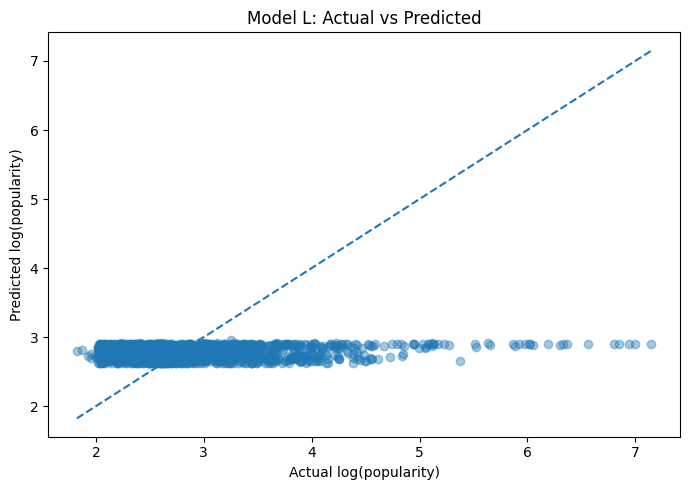

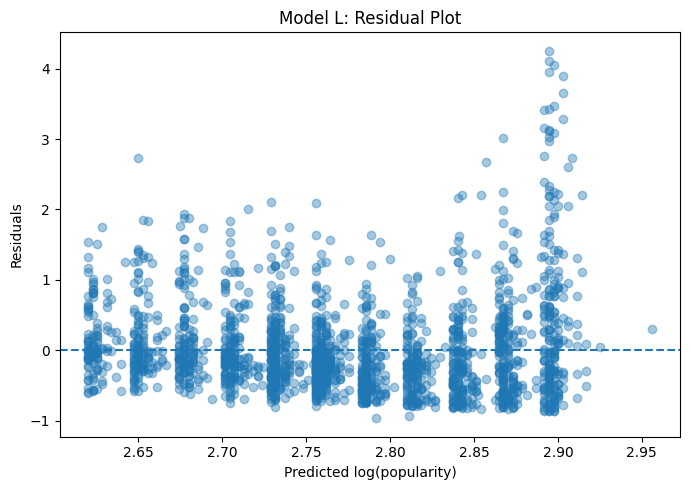

In [67]:
results_L = evaluate_model(
    df=df,
    feature_cols=["person_count_L", "release_year"],
    target_col="popularity",
    log_target=True,
    model_name="Model L: log(popularity) ~ person_count_L + release_year"
)

ols_L = run_statsmodels_ols(
    df=df,
    feature_cols=["person_count_L", "release_year"],
    target_col="popularity",
    log_target=True,
    model_name="Model L OLS: log(popularity) ~ person_count_L + release_year"
)

plot_actual_vs_predicted(results_L, "Model L: Actual vs Predicted")
plot_residuals(results_L, "Model L: Residual Plot")


Model UL: log(popularity) ~ person_count_UL + release_year
Target used: log(popularity)
Coefficients:
  person_count_UL: 0.003940
  release_year: 0.027326
Intercept: -52.400005

Train Metrics
  RMSE: 0.636783
  MAE : 0.465007
  R^2 : 0.016485

Test Metrics
  RMSE: 0.681476
  MAE : 0.478765
  R^2 : 0.019974

Sanity check
  y_test max: 7.148957977830269
  y_test min: 1.823096624537095

Model UL OLS: log(popularity) ~ person_count_UL + release_year
Target used: log(popularity)
                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     61.93
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.85e-27
Time:                        19:28:07   Log-Likelihood:                -9818.7
No. Observations:               10000   AIC:  

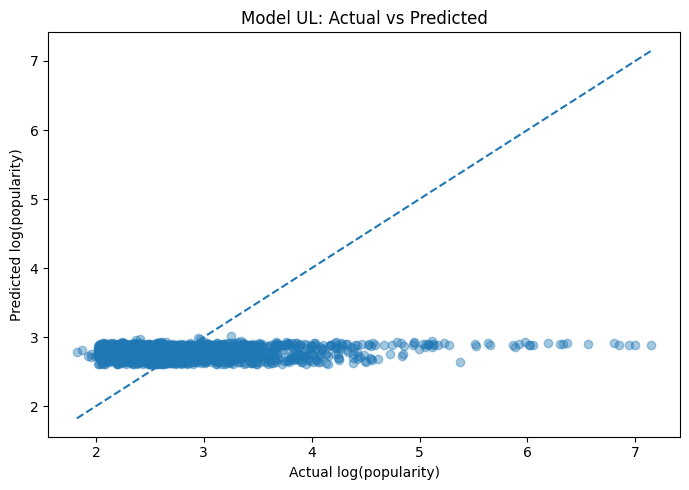

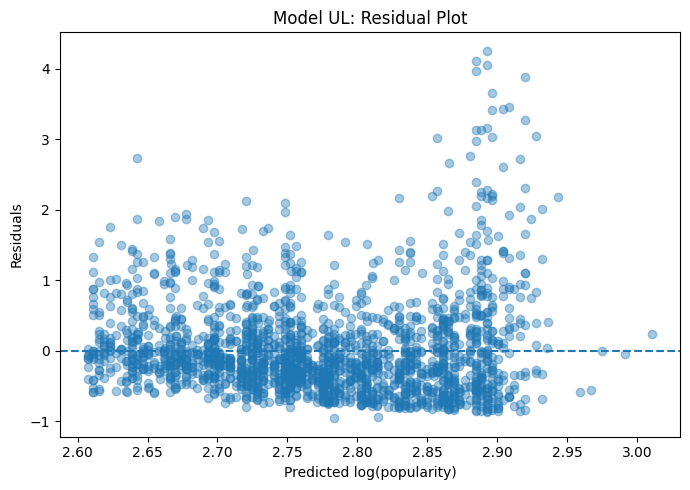

In [68]:
results_UL = evaluate_model(
    df=df,
    feature_cols=["person_count_UL", "release_year"],
    target_col="popularity",
    log_target=True,
    model_name="Model UL: log(popularity) ~ person_count_UL + release_year"
)

ols_UL = run_statsmodels_ols(
    df=df,
    feature_cols=["person_count_UL", "release_year"],
    target_col="popularity",
    log_target=True,
    model_name="Model UL OLS: log(popularity) ~ person_count_UL + release_year"
)

plot_actual_vs_predicted(results_UL, "Model UL: Actual vs Predicted")
plot_residuals(results_UL, "Model UL: Residual Plot")

In [69]:
comparison_table = pd.DataFrame({
    "Model": [
        "Baseline: release_year",
        "Model L: person_count_L + release_year",
        "Model UL: person_count_UL + release_year",
    ],
    "Test_RMSE": [
        baseline_results["test_rmse"],
        results_L["test_rmse"],
        results_UL["test_rmse"],
    ],
    "Test_MAE": [
        baseline_results["test_mae"],
        results_L["test_mae"],
        results_UL["test_mae"],
    ],
    "Test_R2": [
        baseline_results["test_r2"],
        results_L["test_r2"],
        results_UL["test_r2"],
    ],
    "OLS_R2": [
        baseline_ols.rsquared,
        ols_L.rsquared,
        ols_UL.rsquared,
    ],
    "OLS_Adj_R2": [
        baseline_ols.rsquared_adj,
        ols_L.rsquared_adj,
        ols_UL.rsquared_adj,
    ],
    "AIC": [
        baseline_ols.aic,
        ols_L.aic,
        ols_UL.aic,
    ],
    "BIC": [
        baseline_ols.bic,
        ols_L.bic,
        ols_UL.bic,
    ]
})

comparison_table

,Model,Test_RMSE,Test_MAE,Test_R2,OLS_R2,OLS_Adj_R2,AIC,BIC
0,Baseline: release_year,0.682316,0.479348,0.017557,0.016450,0.016351,19653.064965,19667.485646
1,Model L: person_count_L + release_year,0.682146,0.479295,0.018047,0.016658,0.016462,19652.944446,19674.575467
2,Model UL: person_count_UL + release_year,0.681476,0.478765,0.019974,0.017599,0.017402,19643.377288,19665.008309
